# 01: What the market looks like

**The question this project answers:** is there a tradeable edge in Polymarket's daily temperature
markets? Every day the exchange lists *Highest temperature in New York on 3 October?* for 56
cities, with one YES/NO contract per 2 °F or 1 °C bucket. Weather forecasts are public and good. If
the prices lag them, a model should be able to tell.

This notebook looks at the market before any modelling: how many markets there are, how good the
prices already are, who loses money in them, and when a market gets listed. It runs the checks in
`weather_edge.market_checks` on the local database, the same code that wrote
`reports/phase1_market_checks.md`.

**The answer it arrives at:** the prices are honest probabilities that sharpen through the day,
takers lose a fraction of a cent a share, and a market exists about two days before its day.
Whatever edge a model has must show up two days out, at maker prices, against a market that is
already well calibrated.

## Setup

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

from weather_edge import config, market_checks

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

con = market_checks.connect(str(config.RESEARCH_DB), str(config.PRICES_DB))
con.execute("SET enable_progress_bar=false")

def q(sql, params=None):
    return con.execute(sql, params or []).df()

## The inventory

**Where do the markets come from?** Polymarket's Gamma API lists every event with its bucket
markets, rules text, volume and resolution. The `inventory` stage pulled all of them, parsed the
city, date, station and bucket edges out of the titles and rules, and stored them in the `markets`
table. One row is one bucket market.

In [2]:
q("""
    SELECT count(DISTINCT event_id) AS events, count(*) AS bucket_markets,
           count(DISTINCT city) AS cities, min(date) AS first_day, max(date) AS last_day,
           round(sum(volume_usd) / 1e6) AS volume_musd
    FROM markets
""")

,events,bucket_markets,cities,first_day,last_day,volume_musd
0,11375,118990,56,2025-01-20,2026-10-01,916.0


In [3]:
q("""
    SELECT city, min(date) AS first_day, count(DISTINCT date) AS days,
           round(sum(volume_usd) / 1e6, 1) AS volume_musd
    FROM markets
    GROUP BY 1
    ORDER BY 3 DESC
    LIMIT 10
""")

,city,first_day,days,volume_musd
0,London,2025-01-22,615,97.4
1,NYC,2025-01-22,613,79.4
2,Dallas,2025-12-04,300,20.4
3,Toronto,2025-12-06,299,20.1
4,Seoul,2025-12-06,299,57.2
5,Seattle,2025-12-05,298,18.7
6,Atlanta,2025-12-05,298,20.6
7,Buenos Aires,2025-12-06,296,16.8
8,Miami,2025-12-04,253,20.6
9,Chicago,2025-12-04,253,18.6


In [4]:
q("""
    SELECT unit, count(DISTINCT event_id) AS events,
           round(avg(bucket_hi - bucket_lo + 1), 1) AS bucket_width
    FROM markets
    WHERE bucket_lo IS NOT NULL AND bucket_hi IS NOT NULL
    GROUP BY 1
""")

,unit,events,bucket_width
0,C,8071,1.0
1,F,3303,2.0


### What one city-day is

**11,375 events, 118,990 bucket markets, 56 cities, 916 million USD of volume.** London and New
York have been listed every day since January 2025. The other cities came in waves, most of them in
December 2025 and the spring of 2026, so they have about 300 days of history or fewer.

An event is one city-day. It has seven, nine or eleven buckets: Fahrenheit buckets are 2 °F wide
("84-85°F"), Celsius buckets 1 °C wide, and the two ends are open ("81°F or below"). Exactly one
bucket resolves YES.

## How good are the prices already?

**If the market were badly calibrated, the edge would be easy.** The first check is the Brier score
of the YES price against the outcome, sampled at fixed hours before the local midnight that ends
the day. The comparison is the Brier score of always predicting the base rate, which is what a
model that knows nothing would get. `build_views` samples the last price at or before each horizon
for every resolved bucket, never a later one.

In [5]:
market_checks.build_views(con)
calibration = market_checks.t1_calibration(con)

brier = calibration["brier"].sort_values("h", ascending=False)
brier

,h,n,brier_market,brier_base_rate
0,30,115162,0.062644,0.086506
1,24,115623,0.061016,0.086527
2,18,115970,0.058963,0.086532
3,12,109330,0.055020,0.090753
4,6,105805,0.003149,0.093051
5,3,98207,0.000879,0.098156
6,1,93509,0.000397,0.101144


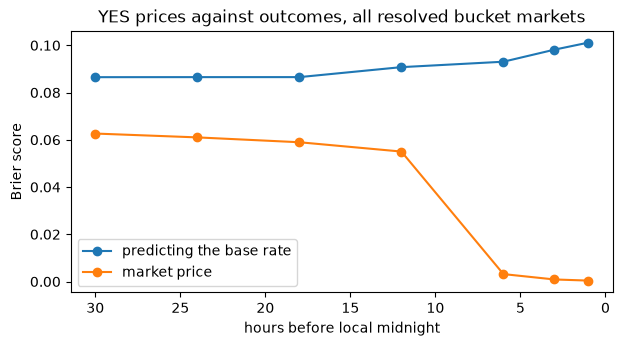

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(brier.h, brier.brier_base_rate, marker="o", label="predicting the base rate")
ax.plot(brier.h, brier.brier_market, marker="o", label="market price")
ax.invert_xaxis()
ax.set_xlabel("hours before local midnight")
ax.set_ylabel("Brier score")
ax.set_title("YES prices against outcomes, all resolved bucket markets")
ax.legend()
plt.show()

In [7]:
# reliability: hit rate against mean price per price band, one day out
reliability = calibration["reliability"]
reliability[reliability.h == 24].drop(columns="h").reset_index(drop=True)

,band,n,mean_price,hit_rate,bias,ci95
0,0.00-0.02,62583,0.004193,0.003100,-0.001093,0.000436
1,0.02-0.05,10991,0.031818,0.024384,-0.007435,0.002884
2,0.05-0.10,8333,0.070673,0.060002,-0.010670,0.005099
3,0.10-0.20,9508,0.145629,0.133572,-0.012057,0.006838
4,0.20-0.35,12684,0.272534,0.259697,-0.012837,0.007631
5,0.35-0.50,8279,0.410266,0.404638,-0.005628,0.010573
6,0.50-0.65,2163,0.555668,0.586685,0.031017,0.020753
7,0.65-0.80,492,0.704032,0.733740,0.029708,0.039057
8,0.80-0.90,134,0.850104,0.858209,0.008104,0.059064
9,0.90-0.95,110,0.924518,0.927273,0.002755,0.048530


### What we got

**The prices are honest, and they sharpen when you would expect.** A day ahead the market's Brier
score is 0.061 against 0.087 for the base rate. Six hours before midnight it is 0.003: by 18:00 the
day's high is usually in and the prices are near certain. In the reliability table the bias per
price band is a cent or less below 50c, where almost all the volume is, and two or three cents on
the few thousand buckets priced 50 to 80c. Nothing you could trade after the spread.

That sets the bar. A model does not beat this market by being calibrated. It beats it by knowing
something the prices do not, and it has to know it before the day's reports arrive.

## Do the prices of one event add up?

**The buckets of one event are exhaustive, so their YES prices should sum to one.** If they sum to
more, whoever is buying YES across the board is overpaying. If they sum to less, there is a riskless
basket to buy.

In [8]:
market_checks.t3_sum_of_yes(con)

,h,n_events,mean_sum,p05,median_sum,p95,share_below_095,share_above_105
0,30,11008,1.045493,0.958000,1.0355,1.153500,0.039517,0.319132
1,24,11055,1.043330,0.959500,1.0360,1.135000,0.037449,0.329082
2,18,11090,1.038042,0.957500,1.0300,1.123275,0.036339,0.262579
3,12,9021,1.026806,0.937000,1.0190,1.121000,0.073606,0.234010
4,6,8308,1.006662,0.989675,1.0045,1.026000,0.016129,0.024434
5,3,7246,1.006864,1.002500,1.0045,1.006500,0.002622,0.008004
6,1,6748,1.005543,1.003000,1.0045,1.006000,0.002223,0.004149


### An overround early, gone by the evening

Thirty hours out the YES prices sum to 1.045 on average and a third of events sit above 1.05. That
is the usual shape of a book where sellers ask more than buyers bid on every bucket: the last
traded prices sit near the asks. By six hours before midnight the sum is 1.007 and the spread is
gone. Nothing here is free money, but it says that a model should sell buckets it thinks are
overpriced rather than buy the cheap ones, because the cheap ones are already priced a little high.

## Who loses money?

**27.9 million on-chain fills say who pays whom.** Each fill has a maker (the resting order) and a
taker (the one who crossed the spread). Grading every fill against the resolution gives the
taker's profit per share before fees. The fills dataset is complete through April 2026 and covers
about 80% of fills after that, so the complete months are the ones to read.

In [9]:
taker = market_checks.t4_maker_taker(con)

overall = taker["overall"]
overall[overall.complete_month].drop(columns="complete_month").reset_index(drop=True)

,era,n_fills,shares,taker_pnl_usd,taker_pnl_per_share,share_taker_buys_yes
0,cwa,14183,7.048530e+05,4.466686e+02,0.000634,0.320948
1,hko,365995,1.212320e+07,-4.860263e+04,-0.004009,0.363609
2,noaa_wrh,504385,1.022104e+07,-4.595131e+03,-0.000450,0.342239
3,wunderground,15138062,4.540282e+08,-1.329826e+06,-0.002929,0.369220


In [10]:
by_side = taker["by_band"].copy()
by_side["taker_c_per_share"] = (100 * by_side.taker_pnl_per_share).round(2)
by_side.pivot(index="band", columns="side", values="taker_c_per_share")

side,taker buys YES,taker sells YES
band,,
0.00-0.02,0.00,-0.16
0.02-0.05,-0.13,-0.83
0.05-0.10,-0.05,-0.72
0.10-0.20,0.32,-0.64
0.20-0.35,-0.09,-0.59
0.35-0.50,0.41,2.63
0.50-0.65,0.25,1.10
0.65-0.80,-5.14,2.11
0.80-0.90,-2.56,4.37


In [11]:
taker["fill_coverage"].tail(8)

,month,n_markets,share_exact,median_ratio
11,2025-12,1624,0.891626,1.000000
12,2026-01,2009,1.000000,1.000000
13,2026-02,2976,0.982191,0.999999
14,2026-03,2476,0.941034,0.999998
15,2026-04,15686,0.898381,0.999998
16,2026-05,17554,0.066993,0.826314
17,2026-06,15951,0.039935,0.776658
18,2026-07,11659,0.049833,0.779841


### What we got

**Takers lose 0.29c a share in the Weather Underground era, over 454 million shares.** Makers earn
the mirror image before fees and rebates. The loss is not spread evenly across prices. A taker who
buys YES at 65 to 98c gives up 1 to 5c a share: that is paying up for the favourite once the day's
high is nearly in. A taker who sells YES at 2 to 35c gives up 0.6 to 0.8c. The one thing takers do
well is sell mid-priced buckets, 35 to 90c, where they make 1 to 4c a share. Those are the sells a
resting maker order ends up on the other side of, and notebook 04 measures what that costs.

Fees do not change the picture. Weather is a fee-enabled category: the taker pays 0.05 × p × (1 − p)
a share, about a cent at typical prices, and the maker pays nothing and gets a quarter of that
back. Every backtest in this project is maker-only for that reason.

## When does a market get listed?

**A two-days-out decision needs a market to exist two days out.** Listing times come from the
`created_at` of the bucket markets. New York is the example; London is similar.

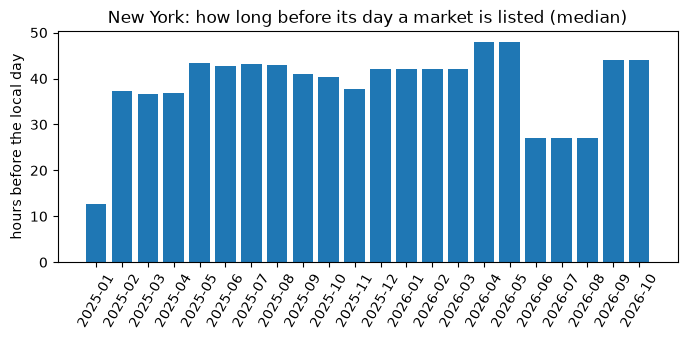

,month,events,median_hours_before_day,listed_by_noon_two_days_before
14,2026-03,31,42.0,29
15,2026-04,30,47.9,29
16,2026-05,32,47.9,30
17,2026-06,29,27.0,5
18,2026-07,31,27.0,0
19,2026-08,31,27.0,2
20,2026-09,30,44.1,29
21,2026-10,1,44.1,1


In [12]:
listing = q("""
    WITH events AS (
        SELECT event_id, date, min(created_at) AS created,
               ((date::TIMESTAMP AT TIME ZONE 'America/New_York') AT TIME ZONE 'UTC') AS day_start
        FROM markets
        WHERE station = 'KLGA'
        GROUP BY 1, 2
    )
    SELECT strftime(date, '%Y-%m') AS month, count(*) AS events,
           round(median(epoch(day_start - created) / 3600.0), 1) AS median_hours_before_day,
           count(*) FILTER (WHERE created <= day_start - INTERVAL 36 HOUR) AS listed_by_noon_two_days_before
    FROM events
    GROUP BY 1
    ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(listing.month, listing.median_hours_before_day)
ax.set_ylabel("hours before the local day")
ax.set_title("New York: how long before its day a market is listed (median)")
ax.tick_params(axis="x", rotation=60)
plt.show()

listing.tail(8)

### About two days, except for one summer

New York markets were listed a median 42 to 48 hours before the local day for most of the history.
In June, July and August 2026 that dropped to 27 hours, so a noon-two-days-before decision had
almost nothing to trade in those months. Since September it is 44 hours again. The backtest counts
an order only when there was a market to place it in, and the holdout in notebook 04 has this
summer in it.

## Is there enough size?

**Shares traded per city-day, and how many of them are at extreme prices** (a YES price under 10c or
over 90c). This is the ceiling for any strategy, not a forecast of what one maker would get filled.

In [13]:
market_checks.t5_capacity(con).head(8)

,city,n_days,mean_shares_per_day,median_shares_per_day,mean_extreme_shares_per_day,mean_fills_per_day
0,Seoul,228,238541.237368,199257.615,194175.810439,7023.859649
1,Shanghai,131,210128.899771,156384.920,165046.349084,8132.305344
2,Hong Kong,129,203595.798837,184599.300,161072.469147,7174.372093
3,London,544,167689.089063,120683.670,137610.957849,4276.996324
4,NYC,541,141896.878817,94221.480,115860.507190,3528.425139
5,Paris,158,139941.170759,113554.280,108344.307342,6733.405063
6,Tokyo,134,121367.696866,100572.015,99765.715149,4966.522388
7,Wellington,181,117421.417735,89083.060,100758.870939,4020.364641


In [14]:
con.close()

## What this notebook establishes

**The market is a calibrated forecaster.** Brier 0.061 a day ahead against 0.087 for the base rate,
no price band with a tradeable bias, and near-certain prices by the evening. Any model edge has to
be information the prices do not have yet, which points to the days before the day.

**Takers pay, a little.** 0.29c a share in the complete months, mostly from buying the favourite
late. Makers collect it. The project trades as a maker and pays no fee.

**A market exists about two days before its day.** That is the earliest a decision can be acted on,
and in the summer of 2026 it was only one day. Everything downstream is scored point in time
against these prices, at noon local, two days, one day and zero days before the day.